## Assignment 6

Python-users: Depending on the version of pytorch_lightning you are running, you might need to modify your code in some places:

    seed_everything can now be imported with "from pytorch_lightning import seed_everything" instead of "from pytorch_lightning.utilities.seed import seed_everything"
    The SimpleModule.classification-module now requires an extra argument "num_classes", set it to the number of classes required for the specific problem


In [1]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
import torch

if torch.backends.mps.is_available():
    print("MPS is available and PyTorch is built with MPS enabled.")
else:
    if not torch.backends.mps.is_built():
        print("MPS is not available because the current PyTorch install was not built with MPS enabled.")
    else:
        print(
            "MPS is not available because the current MacOS version is not 12.3+ and/or you do not have an MPS-enabled device on this machine."
        )

MPS is available and PyTorch is built with MPS enabled.


In [3]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

In [4]:
from torchmetrics import MeanAbsoluteError, R2Score
from torchinfo import summary
from torchvision.io import read_image

In [5]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

In [6]:
from pytorch_lightning import seed_everything

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [7]:
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import Resize, Normalize, CenterCrop, ToTensor

In [8]:
from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers

In [9]:
from ISLP.torch.imdb import load_lookup, load_tensor, load_sparse, load_sequential

In [10]:
from glob import glob
import json

## 10.9.1 - Single Layer Network on Hitters Data

In [11]:
Hitters = load_data("Hitters").dropna()
n = Hitters.shape[0]

In [12]:
model = MS(Hitters.columns.drop("Salary"), intercept=False)
X = model.fit_transform(Hitters).to_numpy()
Y = Hitters["Salary"].to_numpy()

In [13]:
(X_train, X_test, Y_train, Y_test) = train_test_split(X, Y, test_size=1 / 3, random_state=1)

In [14]:
hit_lm = LinearRegression().fit(X_train, Y_train)
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test - Y_test).mean()

np.float64(259.71528833146243)

In [15]:
scaler = StandardScaler(with_mean=True, with_std=True)
lasso = Lasso(warm_start=True, max_iter=30000)
standard_lasso = Pipeline(steps=[("scaler", scaler), ("lasso", lasso)])

In [16]:
X_s = scaler.fit_transform(X_train)
n = X_s.shape[0]
lam_max = np.fabs(X_s.T.dot(Y_train - Y_train.mean())).max() / n
param_grid = {"alpha": np.exp(np.linspace(0, np.log(0.01), 100)) * lam_max}

In [17]:
cv = KFold(10, shuffle=True, random_state=1)
grid = GridSearchCV(lasso, param_grid, cv=cv, scoring="neg_mean_absolute_error")
grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=1, shuffle=True),
             estimator=Lasso(max_iter=30000, warm_start=True),
             param_grid={'alpha': array([255.65755026, 244.03752004, 232.94563812, 222.35789935,
       212.25138966, 202.60423642, 193.39556119, 184.60543446,
       176.21483255, 168.20559645, 160.5603925 , 153.26267486,
       146.29664975, 139.64724123, 133.3000586 , 127.24136521,
       121.45...
        10.81237873,  10.32093943,   9.8518368 ,   9.40405561,
         8.97662677,   8.56862523,   8.17916799,   7.80741218,
         7.45255325,   7.1138232 ,   6.79048896,   6.48185076,
         6.18724064,   5.906021  ,   5.63758323,   5.38134637,
         5.13675587,   4.90328239,   4.68042064,   4.4676883 ,
         4.26462497,   4.07079118,   3.88576744,   3.70915331,
         3.54056657,   3.37964236,   3.2260324 ,   3.07940424,
         2.93944057,   2.80583846,   2.67830877,   2.5565755 ])},
             scoring='neg_mean_absolute_error')

In [18]:
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test - Y_test).mean()

np.float64(257.2382010799497)

In [19]:
class HittersModel(nn.Module):
    def __init__(self, input_size):
        super(HittersModel, self).__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(nn.Linear(input_size, 50), nn.ReLU(), nn.Dropout(0.4), nn.Linear(50, 1))

    def forward(self, x):
        x = self.flatten(x)
        return torch.flatten(self.sequential(x))

In [20]:
hit_model = HittersModel(X.shape[1])

In [21]:
summary(hit_model, input_size=X_train.shape, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (M): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

In [22]:
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t, Y_train_t)

In [23]:
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t, Y_test_t)

In [24]:
max_num_workers = rec_num_workers()

In [25]:
hit_dm = SimpleDataModule(hit_train, hit_test, batch_size=32, num_workers=min(4, max_num_workers), validation=hit_test)

In [26]:
hit_module = SimpleModule.regression(hit_model, metrics={"mae": MeanAbsoluteError()})

In [27]:
hit_logger = CSVLogger("logs", name="hitters")

In [28]:
hit_trainer = Trainer(
    deterministic=True, max_epochs=50, log_every_n_steps=5, logger=hit_logger, callbacks=[ErrorTracker()]
)
hit_trainer.fit(hit_module, datamodule=hit_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | HittersModel | 1.1 K  | train
1 | loss  | MSELoss      | 0      | train
-----------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [29]:
hit_trainer.test(hit_module, datamodule=hit_dm)

Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss             107904.6328125
        test_mae            221.83145141601562
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 107904.6328125, 'test_mae': 221.83145141601562}]

In [30]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)

In [31]:
def summary_plot(
    results, ax, col="loss", valid_legend="Validation", training_legend="Training", ylabel="Loss", fontsize=20
):
    for column, color, label in zip(
        [f"train_{col}_epoch", f"valid_{col}"], ["black", "red"], [training_legend, valid_legend]
    ):
        results.plot(x="epoch", y=column, label=label, marker="o", color=color, ax=ax)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    return ax

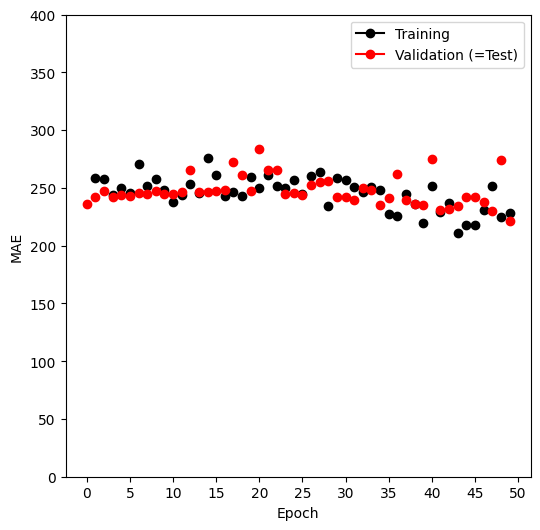

In [32]:
fig, ax = subplots(1, 1, figsize=(6, 6))
ax = summary_plot(hit_results, ax, col="mae", ylabel="MAE", valid_legend="Validation (=Test)")
ax.set_ylim([0, 400])
ax.set_xticks(np.linspace(0, 50, 11).astype(int))

In [33]:
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t - preds).mean()

tensor(221.8315, grad_fn=<MeanBackward0>)

In [34]:
del (
    Hitters,
    hit_model,
    hit_dm,
    hit_logger,
    hit_test,
    hit_train,
    X,
    Y,
    X_test,
    X_train,
    Y_test,
    Y_train,
    X_test_t,
    Y_test_t,
    hit_trainer,
    hit_module,
)

## 10.9.2 - Multilayer Network on the MNIST Digit Data

In [35]:
(mnist_train, mnist_test) = [
    MNIST(root="data", train=train, download=True, transform=ToTensor()) for train in [True, False]
]
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [36]:
mnist_dm = SimpleDataModule(mnist_train, mnist_test, validation=0.2, num_workers=max_num_workers, batch_size=256)

In [37]:
for idx, (X_, Y_) in enumerate(mnist_dm.train_dataloader()):
    print("X: ", X_.shape)
    print("Y: ", Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])
X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])


In [38]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.layer1 = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 256), nn.ReLU(), nn.Dropout(0.4))
        self.layer2 = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3))
        self._forward = nn.Sequential(self.layer1, self.layer2, nn.Linear(128, 10))

    def forward(self, x):
        return self._forward(x)

In [39]:
mnist_model = MNISTModel()

In [40]:
mnist_model(X_).size()

torch.Size([256, 10])

In [41]:
summary(mnist_model, input_data=X_, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

In [42]:
mnist_module = SimpleModule.classification(mnist_model, num_classes=10)
mnist_logger = CSVLogger("logs", name="MNIST")

In [43]:
mnist_trainer = Trainer(deterministic=True, max_epochs=30, logger=mnist_logger, callbacks=[ErrorTracker()])
mnist_trainer.fit(mnist_module, datamodule=mnist_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNISTModel       | 235 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
235 K     Trainable params
0         Non-trainable params
235 K     Total params
0.941     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


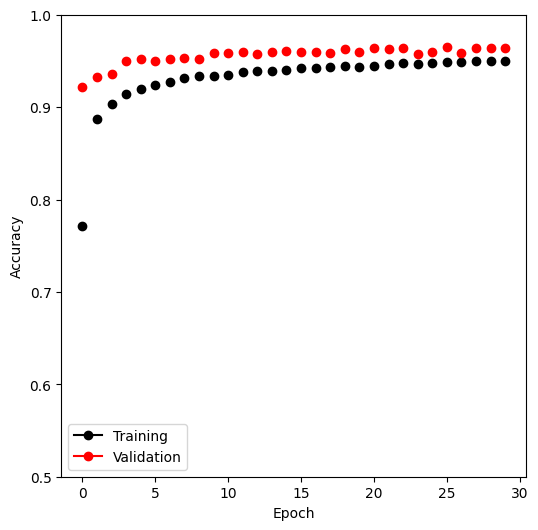

In [44]:
mnist_results = pd.read_csv(mnist_logger.experiment.metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(mnist_results, ax, col="accuracy", ylabel="Accuracy")
ax.set_ylim([0.5, 1])
ax.set_ylabel("Accuracy")
ax.set_xticks(np.linspace(0, 30, 7).astype(int))

In [45]:
mnist_trainer.test(mnist_module, datamodule=mnist_dm)

Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9663000106811523
        test_loss           0.14474152028560638
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.14474152028560638, 'test_accuracy': 0.9663000106811523}]

In [46]:
class MNIST_MLR(nn.Module):
    def __init__(self):
        super(MNIST_MLR, self).__init__()
        self.linear = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

    def forward(self, x):
        return self.linear(x)


mlr_model = MNIST_MLR()
mlr_module = SimpleModule.classification(mlr_model, num_classes=10)
mlr_logger = CSVLogger("logs", name="MNIST_MLR")

In [47]:
mlr_trainer = Trainer(deterministic=True, max_epochs=30, callbacks=[ErrorTracker()])
mlr_trainer.fit(mlr_module, datamodule=mnist_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/henrikformoe/Desktop/Desktop_M2/Projects_25/PSY9511/PSY9511_env/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNIST_MLR        | 7.9

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [48]:
mlr_trainer.test(mlr_module, datamodule=mnist_dm)

Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy          0.916100025177002
        test_loss           0.3469300866127014
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.3469300866127014, 'test_accuracy': 0.916100025177002}]

In [49]:
del (
    mnist_test,
    mnist_train,
    mnist_model,
    mnist_dm,
    mnist_trainer,
    mnist_module,
    mnist_results,
    mlr_model,
    mlr_module,
    mlr_trainer,
)

## 10.9.3 - Convolutional Neural Networks

In [50]:
(cifar_train, cifar_test) = [CIFAR100(root="data", train=train, download=True) for train in [True, False]]

In [51]:
transform = ToTensor()
cifar_train_X = torch.stack([transform(x) for x in cifar_train.data])
cifar_test_X = torch.stack([transform(x) for x in cifar_test.data])
cifar_train = TensorDataset(cifar_train_X, torch.tensor(cifar_train.targets))
cifar_test = TensorDataset(cifar_test_X, torch.tensor(cifar_test.targets))

In [52]:
cifar_dm = SimpleDataModule(cifar_train, cifar_test, validation=0.2, num_workers=max_num_workers, batch_size=128)

In [53]:
for idx, (X_, Y_) in enumerate(cifar_dm.train_dataloader()):
    print("X: ", X_.shape)
    print("Y: ", Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])
X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])


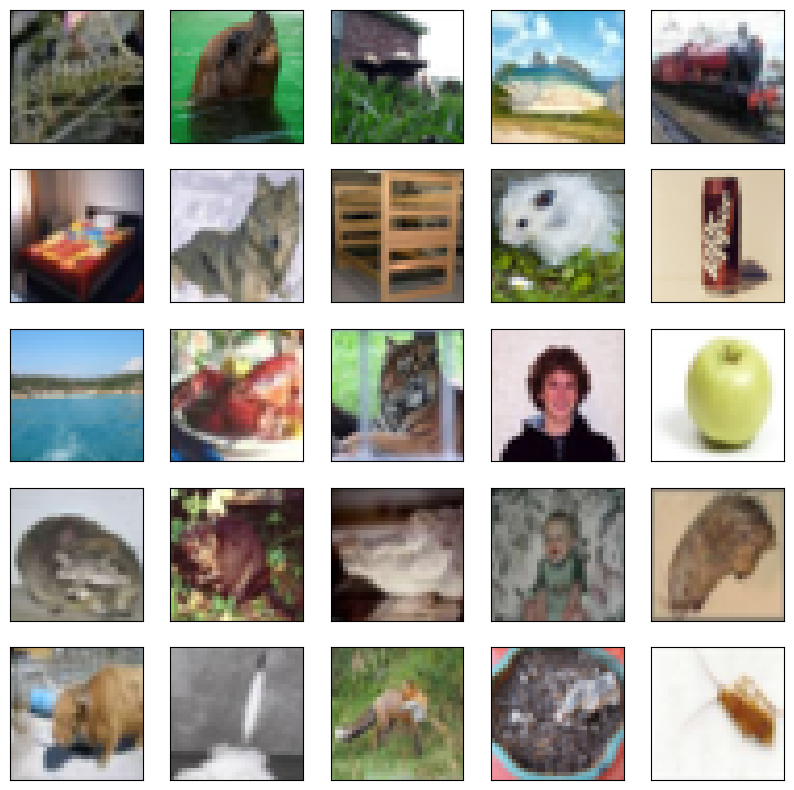

In [54]:
fig, axes = subplots(5, 5, figsize=(10, 10))
rng = np.random.default_rng(4)
indices = rng.choice(np.arange(len(cifar_train)), 25, replace=False).reshape((5, 5))
for i in range(5):
    for j in range(5):
        idx = indices[i, j]
        axes[i, j].imshow(np.transpose(cifar_train[idx][0], [1, 2, 0]), interpolation=None)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

In [55]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BuildingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(3, 3), padding="same")
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))

    def forward(self, x):
        return self.pool(self.activation(self.conv(x)))

In [56]:
class CIFARModel(nn.Module):
    def __init__(self):
        super(CIFARModel, self).__init__()
        sizes = [(3, 32), (32, 64), (64, 128), (128, 256)]
        self.conv = nn.Sequential(*[BuildingBlock(in_, out_) for in_, out_ in sizes])
        self.output = nn.Sequential(nn.Dropout(0.5), nn.Linear(2 * 2 * 256, 512), nn.ReLU(), nn.Linear(512, 100))

    def forward(self, x):
        val = self.conv(x)
        val = torch.flatten(val, start_dim=1)
        return self.output(val)

In [57]:
cifar_model = CIFARModel()
summary(cifar_model, input_data=X_, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CIFARModel                               [128, 3, 32, 32]          [128, 100]                --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 256, 2, 2]          --
│    └─BuildingBlock: 2-1                [128, 3, 32, 32]          [128, 32, 16, 16]         --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 32, 32, 32]         896
│    │    └─ReLU: 3-2                    [128, 32, 32, 32]         [128, 32, 32, 32]         --
│    │    └─MaxPool2d: 3-3               [128, 32, 32, 32]         [128, 32, 16, 16]         --
│    └─BuildingBlock: 2-2                [128, 32, 16, 16]         [128, 64, 8, 8]           --
│    │    └─Conv2d: 3-4                  [128, 32, 16, 16]         [128, 64, 16, 16]         18,496
│    │    └─ReLU: 3-5                    [128, 64, 16, 16]         [128, 64, 16, 16]         --
│    │    └─MaxPool2d: 3-6    

In [58]:
cifar_optimizer = RMSprop(cifar_model.parameters(), lr=0.001)
cifar_module = SimpleModule.classification(cifar_model, num_classes=100, optimizer=cifar_optimizer)
cifar_logger = CSVLogger("logs", name="CIFAR100")

In [59]:
cifar_trainer = Trainer(deterministic=True, max_epochs=30, logger=cifar_logger, callbacks=[ErrorTracker()])
cifar_trainer.fit(cifar_module, datamodule=cifar_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | CIFARModel       | 964 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.858     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [80]:
log_path = cifar_logger.experiment.metrics_file_path
cifar_results = pd.read_csv(log_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(cifar_results, ax, col="accuracy", ylabel="Accuracy")
ax.set_xticks(np.linspace(0, 10, 6).astype(int))
ax.set_ylabel("Accuracy")
ax.set_ylim([0, 1])

NameError: name 'cifar_logger' is not defined

In [61]:
cifar_trainer.test(cifar_module, datamodule=cifar_dm)

Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.4269999861717224
        test_loss            2.45865797996521
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.45865797996521, 'test_accuracy': 0.4269999861717224}]

In [62]:
try:
    for name, metric in cifar_module.metrics.items():
        cifar_module.metrics[name] = metric.to("mps")
    cifar_trainer_mps = Trainer(accelerator="mps", deterministic=True, max_epochs=30)
    cifar_trainer_mps.fit(cifar_module, datamodule=cifar_dm)
    cifar_trainer_mps.test(cifar_module, datamodule=cifar_dm)
except:
    pass

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | CIFARModel       | 964 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.858     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

## 10.9.4 - Using Pretrained CNN Models

In [72]:
resize = Resize((232, 232))
crop = CenterCrop(224)
normalize = Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
imgfiles = sorted([f for f in glob("book_images/*")])
imgs = torch.stack([torch.div(crop(resize(read_image(f))), 255) for f in imgfiles])
imgs = normalize(imgs)
imgs.size()

torch.Size([6, 3, 224, 224])

In [73]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
summary(resnet_model, input_data=imgs, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [6, 3, 224, 224]          [6, 1000]                 --
├─Conv2d: 1-1                            [6, 3, 224, 224]          [6, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [6, 64, 112, 112]         [6, 64, 112, 112]         128
├─ReLU: 1-3                              [6, 64, 112, 112]         [6, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [6, 64, 112, 112]         [6, 64, 56, 56]           --
├─Sequential: 1-5                        [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [6, 64, 56, 56]           [6, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [6, 64, 56, 56]           [6, 64, 56, 56]           128
│    │    └─ReLU: 3-3      

In [74]:
resnet_model.eval()
img_preds = resnet_model(imgs)

In [75]:
img_probs = np.exp(np.asarray(img_preds.detach()))
img_probs /= img_probs.sum(1)[:, None]

In [76]:
labs = json.load(open("imagenet_class_index.json"))
class_labels = pd.DataFrame([(int(k), v[1]) for k, v in labs.items()], columns=["idx", "label"])
class_labels = class_labels.set_index("idx")
class_labels = class_labels.sort_index()

In [77]:
for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df["prob"] = img_probs[i]
    img_df = img_df.sort_values(by="prob", ascending=False)[:3]
    print(f"Image: {imgfile}")
    print(img_df.reset_index().drop(columns=["idx"]))

Image: book_images/Cape_Weaver.jpg
      label      prob
0   jacamar  0.297499
1     macaw  0.068107
2  lorikeet  0.051105
Image: book_images/Flamingo.jpg
            label      prob
0        flamingo  0.609515
1       spoonbill  0.013586
2  American_egret  0.002132
Image: book_images/Hawk_Fountain.jpg
            label      prob
0            kite  0.184682
1           robin  0.084021
2  great_grey_owl  0.061274
Image: book_images/Hawk_cropped.jpg
            label      prob
0            kite  0.453833
1  great_grey_owl  0.015914
2             jay  0.012210
Image: book_images/Lhasa_Apso.jpg
             label      prob
0            Lhasa  0.260317
1         Shih-Tzu  0.097196
2  Tibetan_terrier  0.032820
Image: book_images/Sleeping_Cat.jpg
         label      prob
0  Persian_cat  0.163070
1        tabby  0.074143
2    tiger_cat  0.042578


In [78]:
del (cifar_test, cifar_train, cifar_dm, cifar_module, cifar_logger, cifar_optimizer, cifar_trainer)

### Reflection

2. Reflection

Reflect on what you see in each of the three training performance curves. E.g. (for each training) does the model seem to be training well? Is it converging? Is it overfitting/underfitting? If you saw this in a real-life scenario, what measures would you try to make the model better? If you don't know where to start in interpreting this you can as always send me an email, but I also recommend trying to use GPT UiO to see if it can help you get started. 

Plot 1:
- MAE for both training and validation set is quite stable, and doesn't change much over the course of the 50 epochs. From epoch 30-50 it seems to slighty drop a bit, but through the whole training it shows quite a large spread. It does not seem that the model is learning nor finding much to efficiently learn. I would likely use an optimizer to find suitable hyperparams to help guide learning (e.g. Optuna or Bayesian, then adjust learning rate, and potentially architecture itself if it doesnt learn)
- Not learning at all.

Plot 2:
-  The essential learning seems to take place between epoch 5-10, and it does not seem to improve accuracy much with 30 epochs. However, validation acc is higher than training acc, meaning that the learning is generalizable. I would likely not adjust too much, but rather use this as a baseline, and then e.g. run an optimizer to see if it is possible to squeeze out even a bit more performance.
- Finding usable patterns and learning well

Plot 3:
- The model seems to learn quite efficiently, although with a lower accuracy than previous plots, and the validation accuracy drops approximately from .6 to .4 between train and val set. We could potentially be overfitting to the training set after epoch 8-10 ish. Maybe use early stopping, masking or dropout in order to find more generalizable patterns and help to not overfit training set.
- Overfitting